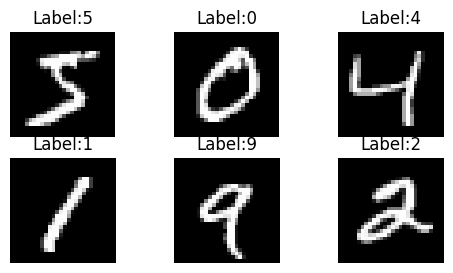

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │        43,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,706 (170.73 KB)

 Trainable params: 43,706 (170.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8560 - loss: 0.5036 - val_accuracy: 0.9678 - val_loss: 0.1104
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9733 - loss: 0.0926 - val_accuracy: 0.9802 - val_loss: 0.0662
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9800 - loss: 0.0666 - val_accuracy: 0.9827 - val_loss: 0.0601
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9841 - loss: 0.0516 - val_accuracy: 0.9801 - val_loss: 0.0633
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9863 - loss: 0.0448 - val_accuracy: 0.9803 - val_loss: 0.0624


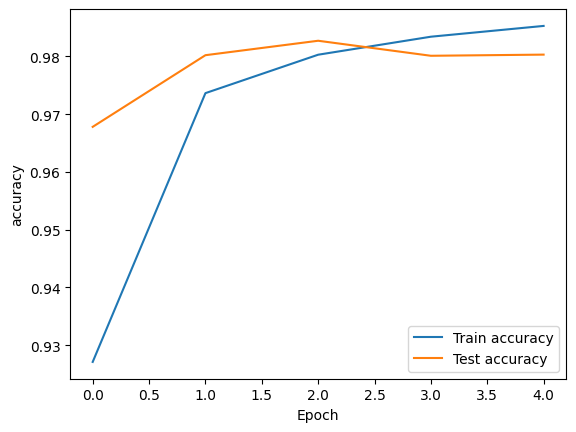

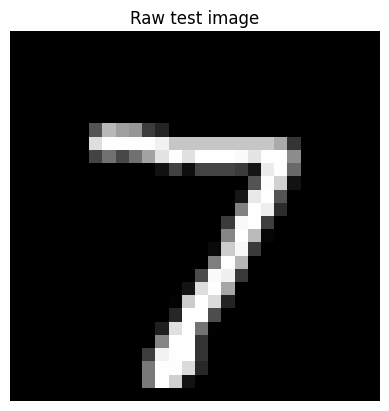

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
model prediction: 7
True label: 7


In [19]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np

(x_train,y_train),(x_test,y_test)=datasets.mnist.load_data()

plt.figure(figsize=(6,3))
for i in range(6):
 plt.subplot(2,3,i+1)
 plt.imshow(x_train[i],cmap="gray")
 plt.title(f"Label:{y_train[i]}")
 plt.axis("off")
plt.show()

x_train=x_train/255.0
x_test=x_test/255.0

x_train=x_train[...,np.newaxis]
x_test=x_test[...,np.newaxis]

model=models.Sequential([
 layers.Conv2D(8,(3,3),activation='relu',input_shape=(28,28,1)),
 layers.MaxPooling2D((2,2)),
 layers.Flatten(),
 layers.Dense(32,activation='relu'),
 layers.Dense(10,activation='softmax')
 ])

model.summary()

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history=model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

plt.plot(history.history['accuracy'],label='Train accuracy')
plt.plot(history.history['val_accuracy'],label='Test accuracy')
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()


test_img=x_test[0]
plt.imshow(test_img.reshape(28,28),cmap="gray")
plt.title("Raw test image")
plt.axis("off")
plt.show()

pred=model.predict(test_img[np.newaxis,...])
print("model prediction:",np.argmax(pred))
print("True label:",y_test[0])

